 # Telco Customer Churn Analysis
### Predicting Customer Churn Using Machine Learning

## Introduction

Customer churn refers to customers discontinuing their services with a company. For subscription-based businesses such as telecommunications providers, customer churn directly impacts revenue and long-term growth. Identifying the factors that contribute to churn can help companies implement targeted retention strategies and reduce customer loss.

This project analyzes customer data from a telecommunications company to explore the drivers of churn and build predictive models capable of identifying customers who are likely to leave.

## Problem Statement

Customer retention is often more cost-effective than acquiring new customers. However, many companies struggle to identify which customers are most likely to discontinue their services.

The goal of this project is to analyze customer characteristics and service usage patterns to understand the factors influencing customer churn. Additionally, this project aims to develop machine learning models that can predict churn based on available customer data.

## Project Objectives

The objectives of this analysis are:

- Understand the structure and characteristics of the dataset
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis to identify patterns associated with churn
- Build machine learning models to predict churn
- Evaluate model performance and interpret results

## Dataset Description

The dataset used in this project contains customer information from a telecommunications company. Each row represents an individual customer and includes demographic information, account details, service subscriptions, and billing information.

The dataset contains 7,043 customers and 21 variables.

The target variable is **Churn**, which indicates whether a customer has discontinued the service.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
df_customer_churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_customer_churn.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_customer_churn.shape

(7043, 21)

In [4]:
df_customer_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleaning and Pre-processing

In [5]:
## The TotalCharges column is currently stored as an object, instead of a numerical value
## Need to convert it into numeric

df_customer_churn['TotalCharges']=pd.to_numeric(df_customer_churn['TotalCharges'], errors='coerce')

In [6]:
## Checking for missing values:
df_customer_churn.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
## Returning the rows with missing values:
df_customer_churn[df_customer_churn['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
## Dropping the rows with missing values because they contribute no important information since all those...
## ...customers have a tenure of zero, meaning they likely just signed up but never actually used the service
## 11 entries out of 7043 are negligible and wont affect the insights

df_customer_churn = df_customer_churn.dropna()

In [9]:
df_customer_churn.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Exploratory Data Analysis (EDA)

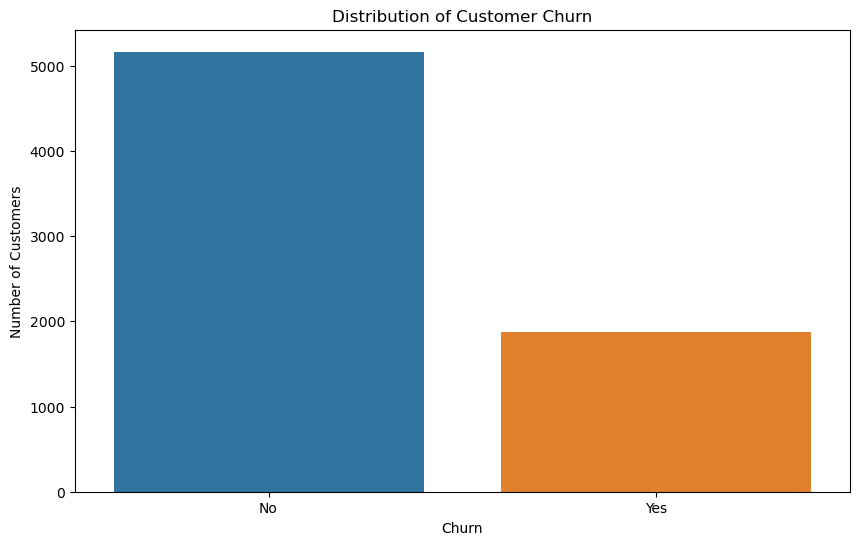

In [10]:
## Distribution Plots:
## Churn distribution - helps understand class balance between the customers who churned vs those who didn't

plt.figure(figsize=(10,6))

sns.countplot(x='Churn', data = df_customer_churn)

plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

The distribution of the churn variable shows that the majority of customers did not churn, while a smaller portion discontinued their service. This indicates a class imbalance in the dataset, which is typical in churn prediction problems and should be considered when building machine learning models.

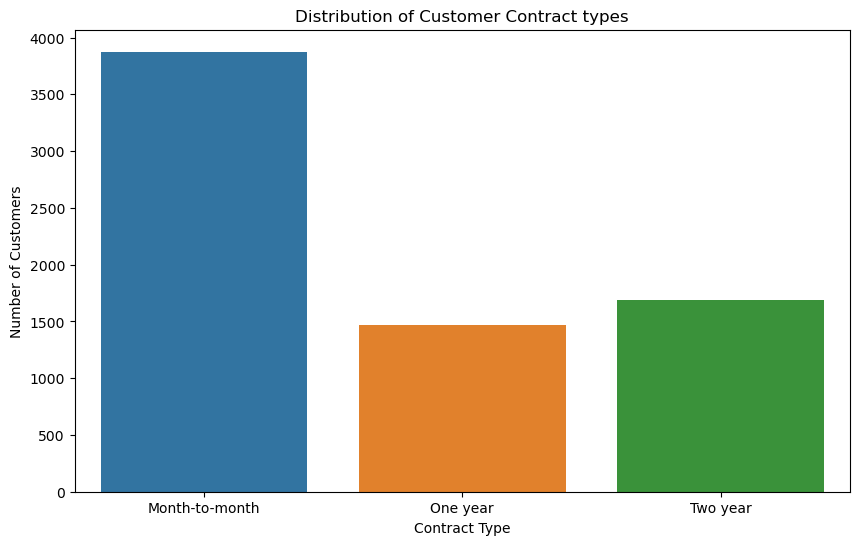

In [11]:
## Contract types distribution
plt.figure(figsize=(10,6))

sns.countplot(x='Contract', data = df_customer_churn)

plt.title('Distribution of Customer Contract types')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

Most customers are on month-to-month contracts (~3,900), while one-year and two-year contracts are less common. This indicates that a large portion of the customer base is on short-term plans, which may contribute to higher churn.

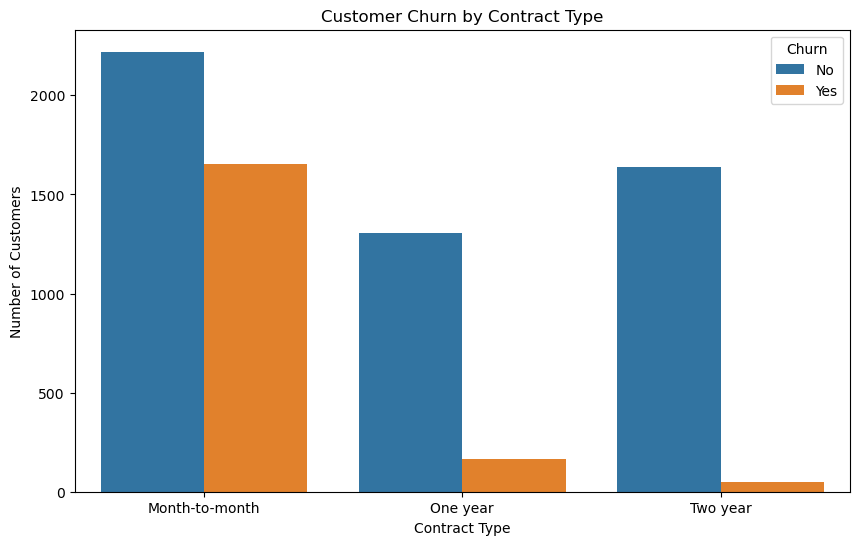

In [12]:
## Distribution of Customer Churn by Contract Type
plt.figure(figsize=(10,6))

sns.countplot(x='Contract', hue='Churn', data = df_customer_churn)

plt.title('Customer Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

Customers on month-to-month contracts have the highest churn, while one- and two-year contracts show stronger retention. This indicates that longer-term contracts are associated with lower churn risk

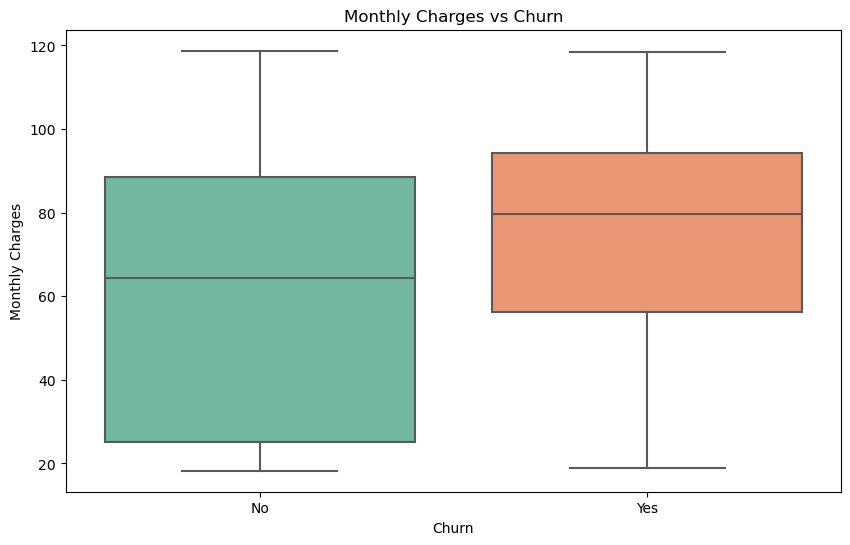

In [13]:
## Monthly Charges vs Customer Churn
plt.figure(figsize=(10,6))

sns.boxplot(x='Churn', y='MonthlyCharges', data = df_customer_churn, palette='Set2')

plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

This plot compares monthly charges between churned and non-churned customers. Customers who churn exhibit a higher median monthly charge, indicating that pricing is a key driver of churn. This suggests that customers with higher subscription costs may be more sensitive to price and therefore more likely to discontinue the service.

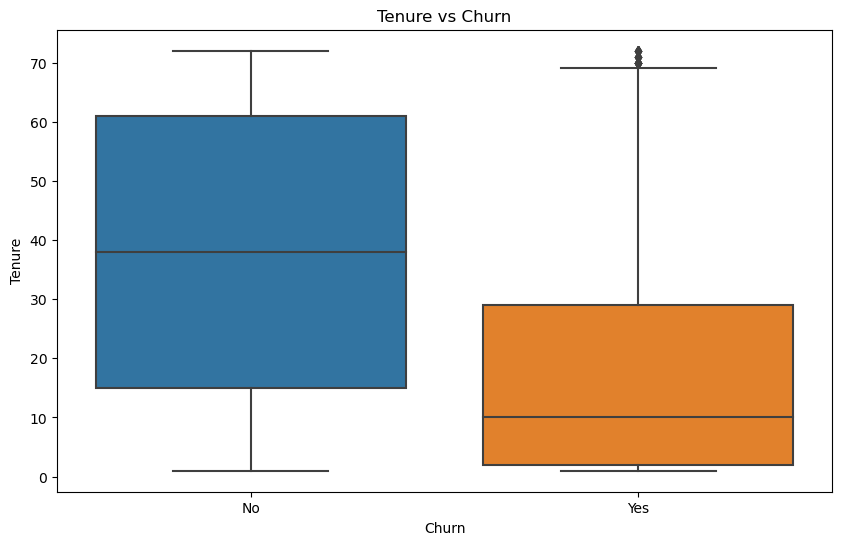

In [14]:
## Tenure vs Customer Churn
plt.figure(figsize=(10,6))

sns.boxplot(x='Churn', y='tenure', data = df_customer_churn)

plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')

plt.show()

This plot illustrates the distribution of customer tenure by churn status. Customers who churn have notably lower median tenure compared to those who remain, indicating that churn is more prevalent among newer customers. In contrast, customers with longer tenure exhibit higher retention, suggesting that customer loyalty increases over time. This highlights the importance of targeting early-stage customers with retention initiatives.

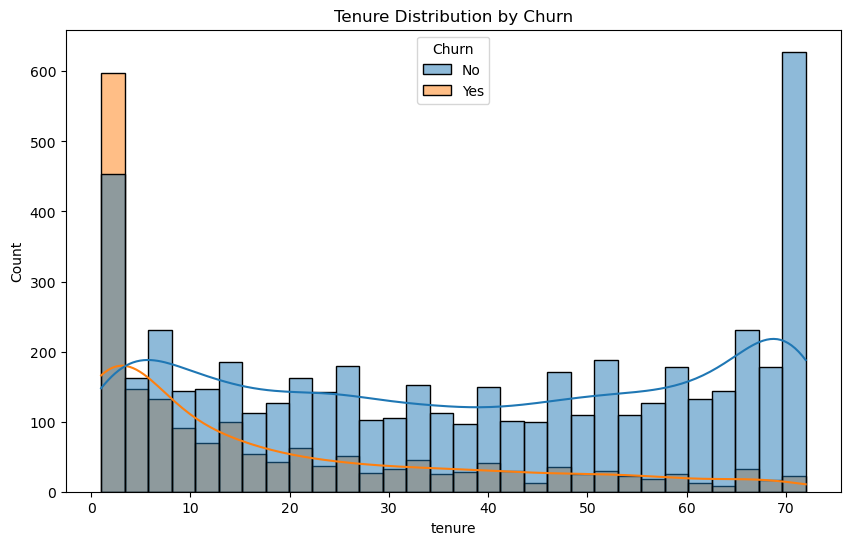

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_customer_churn, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

This distribution highlights a clear difference in tenure between churned and retained customers. Churned customers are predominantly clustered at low tenure values, indicating that churn occurs most frequently among newer users. Meanwhile, non-churning customers are more evenly distributed and show higher concentrations at longer tenure levels. This reinforces the idea that customer retention improves over time and that early-stage engagement is critical to reducing churn.

Text(0.5, 1.0, 'Distribution of Customer Tenure')

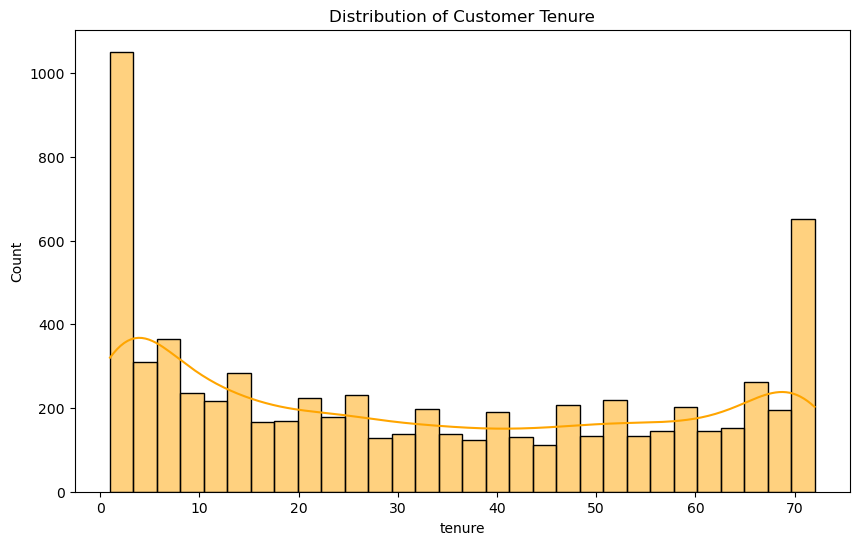

In [16]:
## Distribution of tenure (to see how long customers typically stay using the service)

plt.figure(figsize=(10,6))
sns.histplot(df_customer_churn['tenure'], bins=30, color = 'orange', kde=True)
plt.title('Distribution of Customer Tenure')

Text(0.5, 1.0, 'Distribution of Monthly Charges')

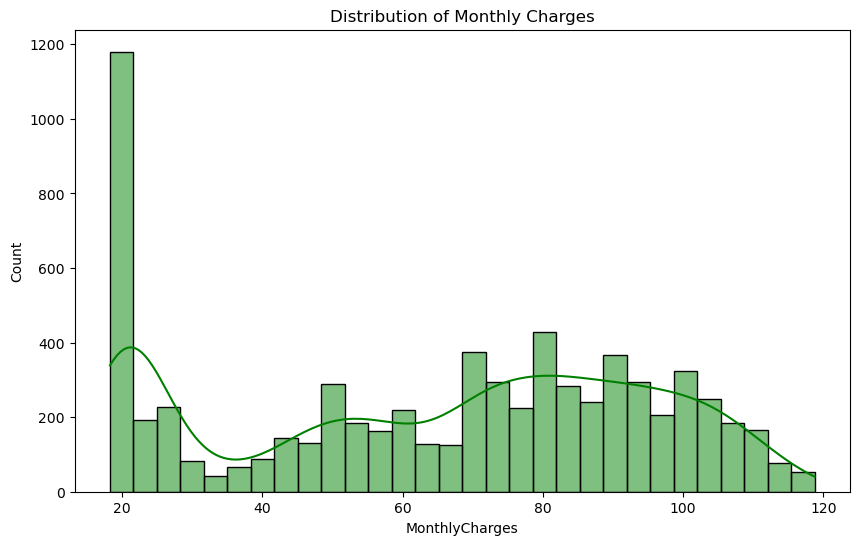

In [17]:
## Distribution of Monthly Charges

plt.figure(figsize=(10,6))
sns.histplot(df_customer_churn['MonthlyCharges'], bins=30, color = 'green', kde=True)
plt.title('Distribution of Monthly Charges')

Text(0.5, 1.0, 'Distribution of Total Charges')

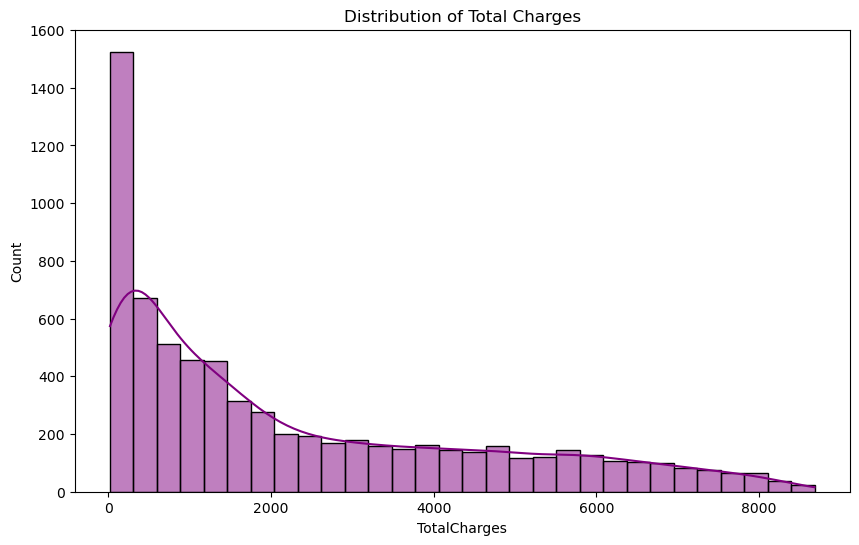

In [18]:
## Distribution of Total Charges

plt.figure(figsize=(10,6))
sns.histplot(df_customer_churn['TotalCharges'], bins=30, color = 'purple', kde=True)
plt.title('Distribution of Total Charges')

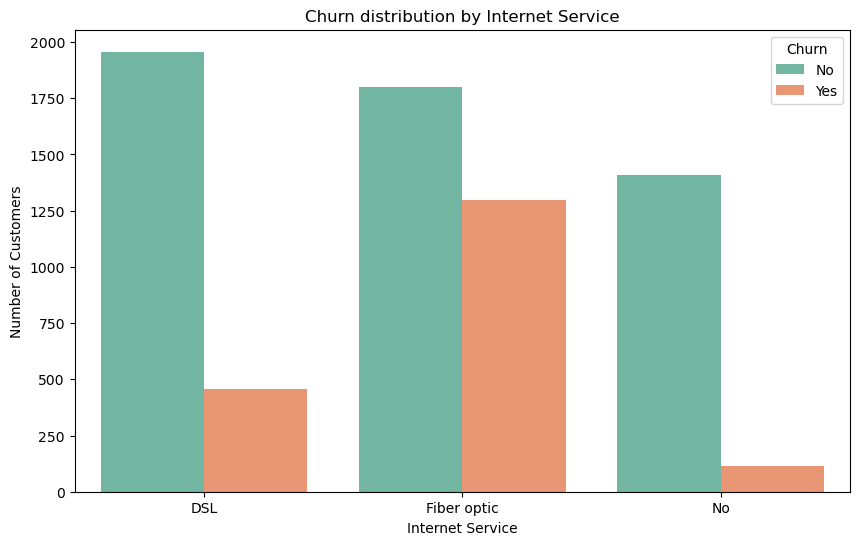

In [19]:
## Churn distribution by Internet Service

plt.figure(figsize =(10,6))

sns.countplot(x='InternetService', hue='Churn', data = df_customer_churn, palette='Set2')

plt.title('Churn distribution by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

This plot compares churn behavior across different internet service types. Customers using fiber optic services exhibit the highest churn levels in absolute terms compared to other groups. In contrast, DSL users and customers without internet service show significantly lower churn counts. This suggests that fiber optic services may be associated with higher churn risk, although further analysis using churn rates would provide a more precise comparison.

<Axes: xlabel='DeviceProtection', ylabel='count'>

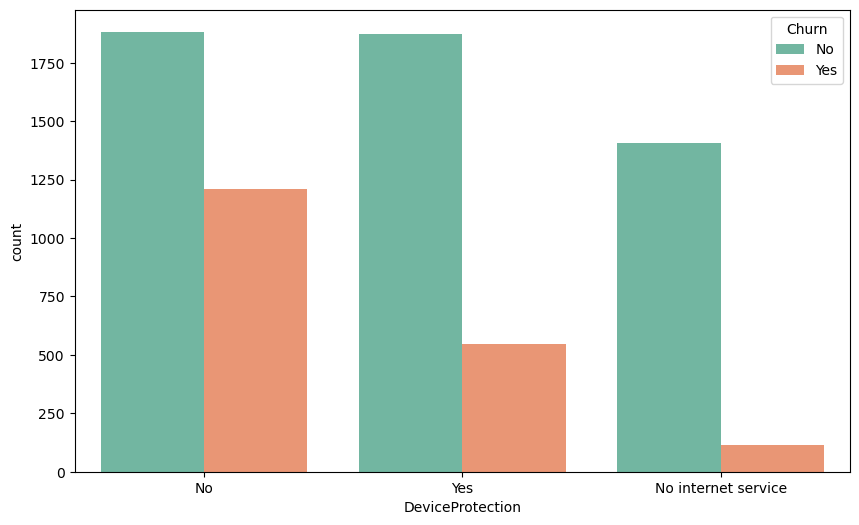

In [20]:
## Device Protection vs Churn
plt.figure(figsize=(10,6))

sns.countplot(x='DeviceProtection', hue='Churn', data = df_customer_churn, palette = 'Set2')

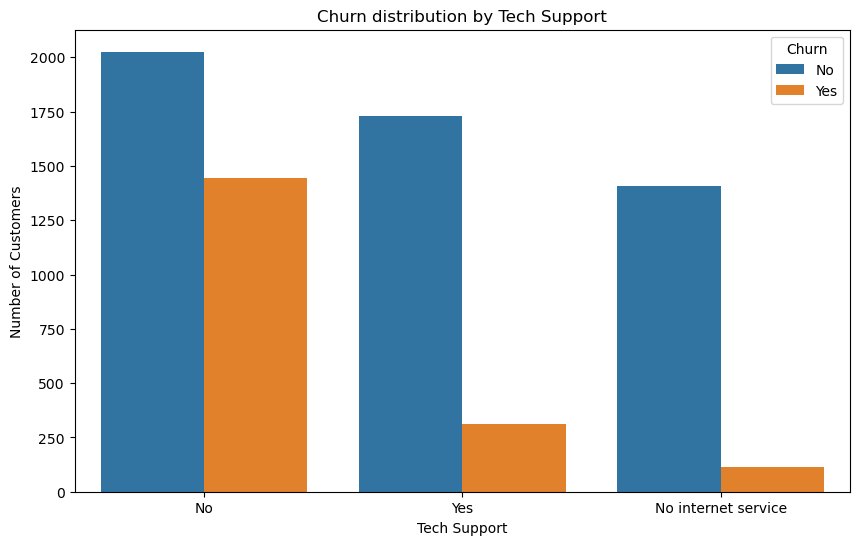

In [21]:
## Tech Support vs Churn
plt.figure(figsize=(10,6))
sns.countplot(x='TechSupport', hue='Churn', data = df_customer_churn)
plt.title('Churn distribution by Tech Support')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.show()

The analysis indicates that the absence of technical support is strongly associated with higher churn rates. Customers without tech support exhibit a significantly greater likelihood of leaving the service, while those with support show improved retention. This highlights the importance of customer support services in enhancing user experience and reducing churn risk.

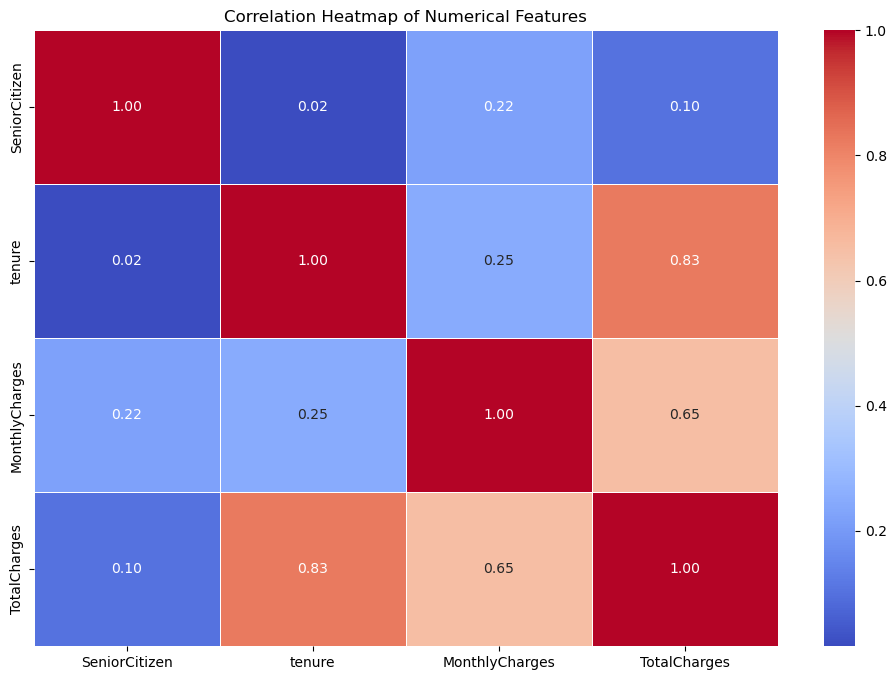

In [22]:
## Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_customer_churn.corr(numeric_only=True),
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

While the correlation heatmap provides insight into relationships among numerical variables, the primary drivers of churn in this dataset are categorical features such as contract type and service subscriptions. Therefore, categorical analysis plays a more significant role in understanding churn behavior.

## Feature Engineering

In [23]:
## Convert Target Variable into numerical
df_customer_churn['Churn'] = df_customer_churn['Churn'].map({'Yes':1, 'No':0})

In [24]:
## Drop unnecessary columns
df_customer_churn = df_customer_churn.drop('customerID', axis=1)

In [25]:
## Convert Categorical Variables
df_customer_churn = pd.get_dummies(df_customer_churn, drop_first=True)

In [26]:
df_customer_churn.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## Train-Test Split

In [27]:
from sklearn.model_selection import train_test_split

X = df_customer_churn.drop('Churn', axis=1)
y = df_customer_churn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Model Building (First - baseline Model)

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [29]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Model 2 - Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [31]:
## Using grid search to get the best parameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

grid.best_params_

{'max_depth': 10, 'n_estimators': 100}

In [32]:
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

pred_tuned = rf_tuned.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, pred_tuned))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



Hyperparameter tuning slightly improved Random Forest recall (0.46 → 0.48), but it still underperformed compared to Logistic Regression (recall = 0.51). Despite similar accuracy (~79%), Logistic Regression was more effective at identifying churn, suggesting that a simpler linear model captures the relationships in the data better than a more complex model.

In [33]:
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

tenure                            0.185169
TotalCharges                      0.153426
MonthlyCharges                    0.126237
InternetService_Fiber optic       0.068573
Contract_Two year                 0.054246
PaymentMethod_Electronic check    0.049571
OnlineSecurity_Yes                0.039331
Contract_One year                 0.036109
TechSupport_Yes                   0.030241
PaperlessBilling_Yes              0.020304
dtype: float64

Feature importance shows that tenure is the strongest predictor of churn, with newer customers more likely to leave. Pricing variables (monthly and total charges) also contribute significantly, along with internet service type and contract duration, where longer-term contracts reduce churn. Additionally, customers using electronic check payments are more likely to churn, while services like online security and tech support are associated with higher retention.

## Logistic Regression - Final Attempt (Optimized)

In [34]:
##Implementing Logistic regression again after balancing the class weights between churned and non-churned customers
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(class_weight = 'balanced', max_iter = 1000)


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
log_model.fit(X_train_scaled, y_train)
pred = log_model.predict(X_test_scaled)

In [37]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



After addressing class imbalance using weighted Logistic Regression and applying feature scaling, the model achieved a significant improvement in churn recall, increasing from 51% to 79%. Although overall accuracy decreased slightly, this trade-off is justified from a business perspective, as the model is now able to identify a much larger proportion of customers at risk of churning. While precision declined, the increased recall ensures that fewer churners are missed, which is critical for implementing effective customer retention strategies.

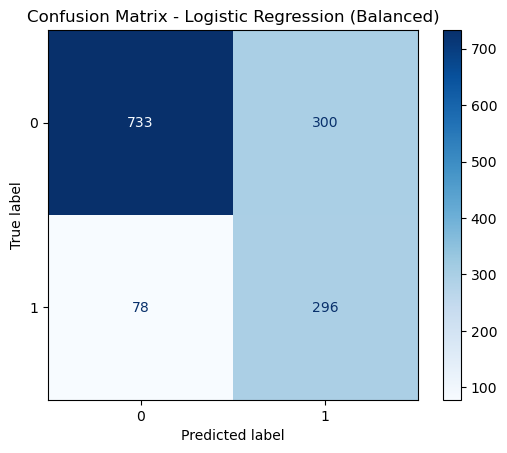

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression (Balanced)')
plt.show()

The confusion matrix shows strong churn detection, with 296 true positives and 78 false negatives (recall ≈ 0.79). While false positives are higher (300), this trade-off is acceptable, as identifying at-risk customers is more important than avoiding false alarms.

In [39]:
probs = log_model.predict_proba(X_test_scaled)[:,1]

pred_custom = (probs > 0.4).astype(int)

In [40]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

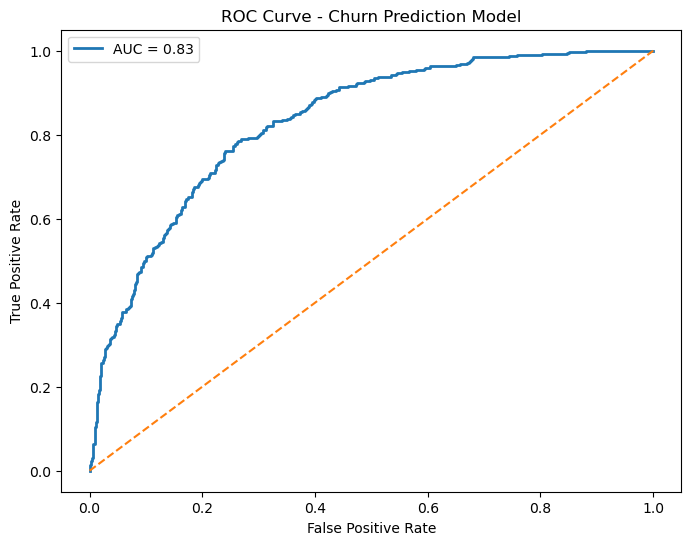

In [41]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", linewidth=2)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction Model')
plt.legend()

plt.show()


The model predicts churn probabilities, which are converted into class labels using a custom threshold of 0.4 to improve recall. This adjustment increases the model’s ability to identify at-risk customers, which is critical in a churn prediction context.

To evaluate performance across all possible thresholds, the Receiver Operating Characteristic (ROC) curve is used. The model achieves an AUC of 0.83, indicating strong ability to distinguish between churned and non-churned customers. The curve demonstrates a favorable trade-off between true positive and false positive rates, confirming that the model has strong discriminative power and is suitable for customer retention applications.

## Results and Insights

The analysis shows that churn is highest among customers on month-to-month contracts, those with higher monthly charges, and newer customers with shorter tenure. In contrast, customers on longer-term contracts and those with longer tenure are more likely to stay, highlighting the importance of early retention and pricing.

The logistic regression model performed well, achieving an AUC of 0.83 and a recall of 0.79 for churn prediction after addressing class imbalance. Overall, the results suggest that contract type, pricing, and early customer experience are key drivers of churn and can be used to guide targeted retention strategies.

## Conclusion

This project identified contract type, tenure, and monthly charges as the strongest drivers of customer churn. Customers on month-to-month contracts, with shorter tenure, and higher monthly charges are significantly more likely to churn, while long-term contracts and extended tenure are associated with higher retention.

The logistic regression model achieved an AUC of 0.83 and a recall of 0.79 for churn prediction, demonstrating strong ability to identify at-risk customers. These results can be used to prioritize retention efforts, particularly by targeting new customers, reviewing pricing strategies, and encouraging longer-term contracts.